In [1]:
# Import libraries + load the dataset
import pandas as pd
import numpy as np

# Update this path if needed
DATA_PATH = "flood.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (50000, 21)
Columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [2]:
#  Quick structural check (dtypes, missing values, duplicates)
print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Data types:
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments                        int64
IneffectiveDisasterPreparedness      int64
DrainageSystems                      int64
CoastalVulnerability                 int64
Landslides                           int64
Watersheds                           int64
DeterioratingInfrastructure          int64
PopulationScore                      int64
WetlandLoss                          int64
InadequatePlanning                   int64
PoliticalFactors                     int64
FloodProbability                   float64
dtype: object

Missing values per column:
MonsoonIntensity                   0
Topogr

In [3]:
#  Basic cleaning (drop duplicates, standardize column names, sanity checks)
# 1) Drop duplicate rows (if any)
df = df.drop_duplicates().reset_index(drop=True)

# 2) Standardize column names (trim spaces; keep original style but safer)
df.columns = [c.strip() for c in df.columns]

# 3) Ensure target column exists
TARGET_COL = "FloodProbability"
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found!"

print("After cleaning shape:", df.shape)


After cleaning shape: (50000, 21)


In [4]:
# Final check after preprocessing

print("Final dataset shape after preprocessing:", df.shape)

print("\nNumber of features (including target):", df.shape[1])
print("Number of samples:", df.shape[0])

df.head()


Final dataset shape after preprocessing: (50000, 21)

Number of features (including target): 21
Number of samples: 50000


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [5]:
# Cell 8: Descriptive Statistics

print("Descriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


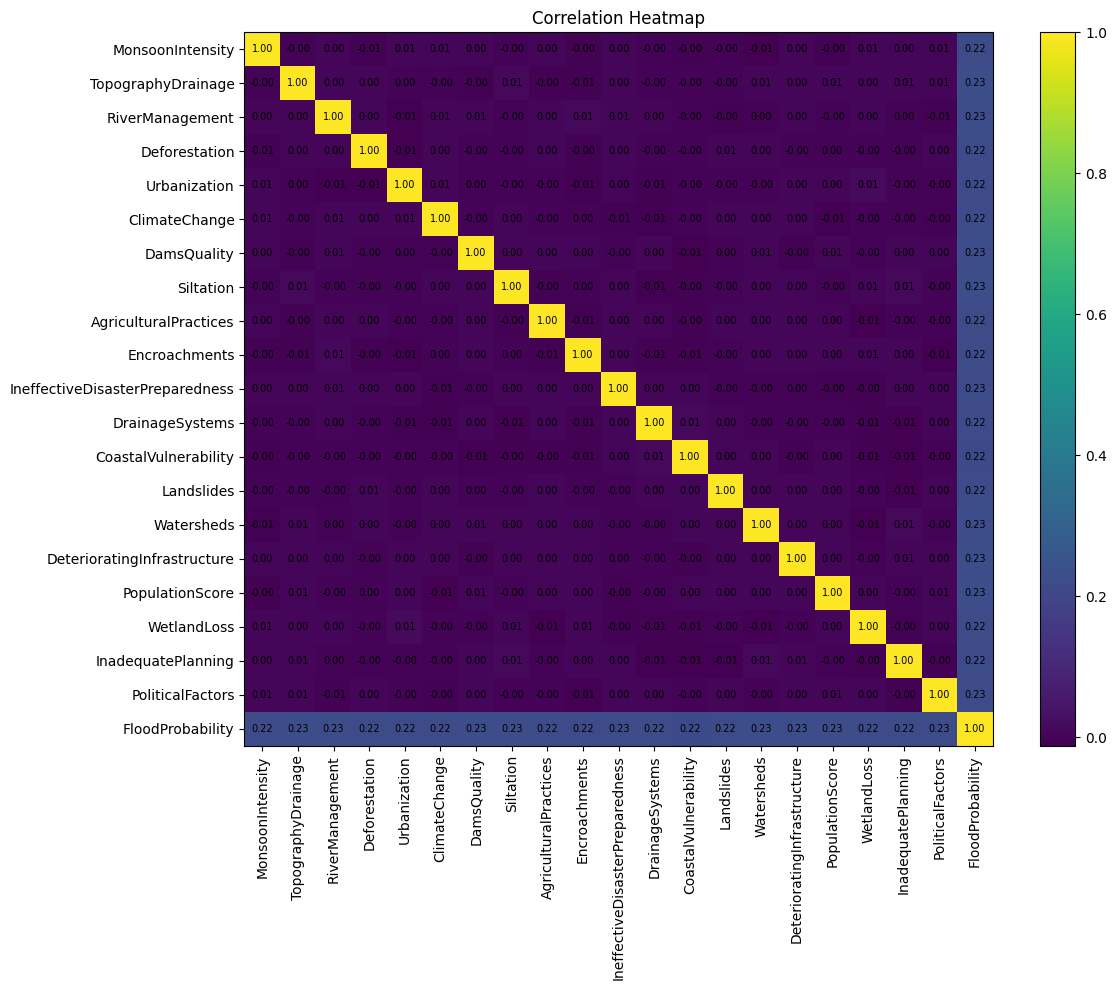

In [6]:
# Cell 9: Correlation Heatmap (annot=True)

import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Annotate values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


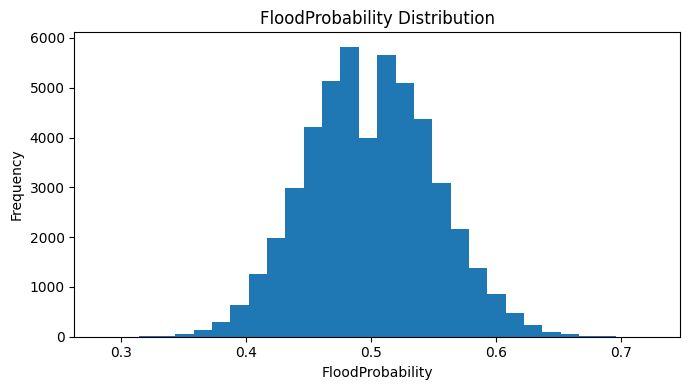

In [7]:
# Cell 10: Target Distribution

plt.figure(figsize=(7, 4))
plt.hist(df["FloodProbability"], bins=30)
plt.title("FloodProbability Distribution")
plt.xlabel("FloodProbability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


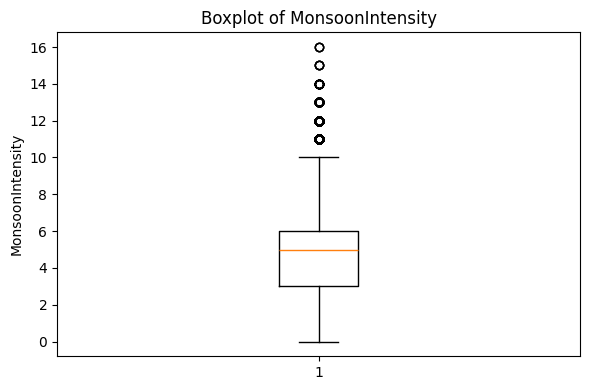

In [8]:
# Boxplot for a Single Column

import matplotlib.pyplot as plt

column_name = "MonsoonIntensity"   # change column here if needed

plt.figure(figsize=(6, 4))
plt.boxplot(df[column_name], showfliers=True)

plt.title(f"Boxplot of {column_name}")
plt.ylabel(column_name)

plt.tight_layout()
plt.show()


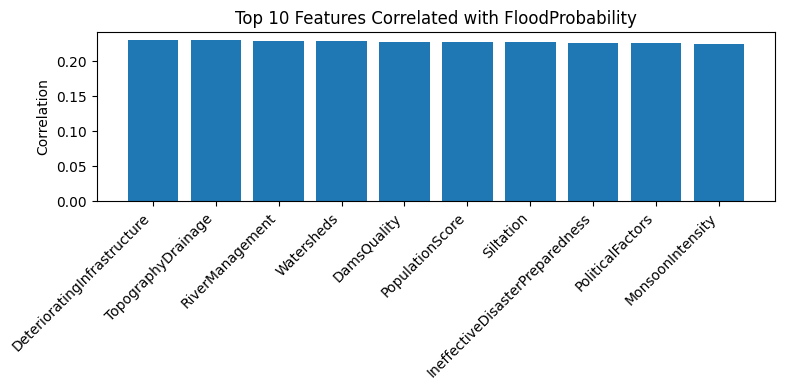

In [9]:
# Cell 12: Top 10 Correlated Features with Target

corr = df.corr()
target_corr = (
    corr["FloodProbability"]
    .drop("FloodProbability")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.bar(target_corr.index, target_corr.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Features Correlated with FloodProbability")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


/tmp/ipykernel_4877/1013702891.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("Urbanization_Level")["FloodProbability"].mean()


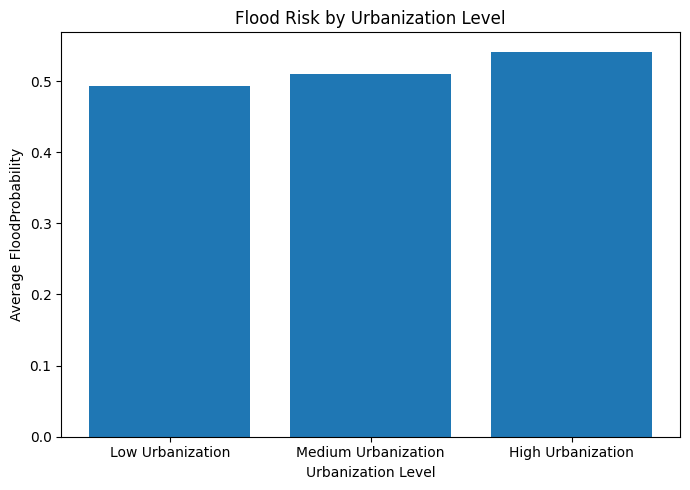

In [10]:
# Meaningful Plot: Flood Risk by Urbanization Level

import matplotlib.pyplot as plt
import pandas as pd

# Create categorical levels for Urbanization
df["Urbanization_Level"] = pd.cut(
    df["Urbanization"],
    bins=3,
    labels=["Low Urbanization", "Medium Urbanization", "High Urbanization"]
)

# Compute average FloodProbability per level
grouped = df.groupby("Urbanization_Level")["FloodProbability"].mean()

plt.figure(figsize=(7, 5))
plt.bar(grouped.index, grouped.values)

plt.xlabel("Urbanization Level")
plt.ylabel("Average FloodProbability")
plt.title("Flood Risk by Urbanization Level")

plt.tight_layout()
plt.show()


In [11]:
# Remove visualization-only column
if "Urbanization_Level" in df.columns:
    df = df.drop(columns=["Urbanization_Level"])
    print("Urbanization_Level removed.")

# create X and y
X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

print("Current feature shape:", X.shape)

Urbanization_Level removed.
Current feature shape: (50000, 20)


In [12]:
# Cell 14: Label Encoding (only if categorical columns exist)

from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=["object"]).columns
print("Categorical columns found:", list(categorical_cols))

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("Label encoding done .")

Categorical columns found: []
Label encoding done .


In [13]:
# Cell 15: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (40000, 20) X_test: (10000, 20)
y_train: (40000,) y_test: (10000,)


In [14]:
# Cell 16: Standard Scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaling complete.
Scaled X_train shape: (40000, 20)
Scaled X_test shape: (10000, 20)


In [15]:
# ------------------------------------------------------------
# Support Vector Regression (SVR)
# A nonlinear regression model that finds the best curve
# fitting the relationship between input features and flood risk
# ------------------------------------------------------------

from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create the SVR model
svr = SVR(kernel="rbf", C=10, epsilon=0.01)

# Train the model using training data
svr.fit(X_train_scaled, y_train)

# Predict flood probability on unseen test data
y_pred_svr = svr.predict(X_test_scaled)

# Evaluate performance
print("------ SVR Regressor ------")
print("R2 Score:", r2_score(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))

------ SVR Regressor ------
R2 Score: 0.9865606859367066
MAE: 0.00418253990593599
RMSE: 0.005785478719329752


In [16]:
# ------------------------------------------------------------
# Random Forest Regressor
# Uses many decision trees and averages their predictions
# Good at handling complex environmental relationships
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate performance
print("\n------ Random Forest Regressor ------")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


------ Random Forest Regressor ------
R2 Score: 0.7335442648971846
MAE: 0.020329532499999973
RMSE: 0.025761033659142996


In [17]:
# ------------------------------------------------------------
# XGBoost Regressor
# Advanced boosting algorithm that corrects previous errors
# Often provides the best accuracy in prediction problems
# ------------------------------------------------------------

from xgboost import XGBRegressor

# Create the model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgb.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_xgb = xgb.predict(X_test_scaled)

# Evaluate performance
print("\n------ XGBoost Regressor ------")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


------ XGBoost Regressor ------
R2 Score: 0.9560144472668926
MAE: 0.008137820392370225
RMSE: 0.010466603583208896


In [18]:
# ------------------------------------------------------------
# Compare performance of all models in one table
# ------------------------------------------------------------

import pandas as pd

results = pd.DataFrame({
    "Model": ["SVR", "Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,SVR,0.986561,0.004183,0.005785
1,Random Forest,0.733544,0.020330,0.025761
2,XGBoost,0.956014,0.008138,0.010467


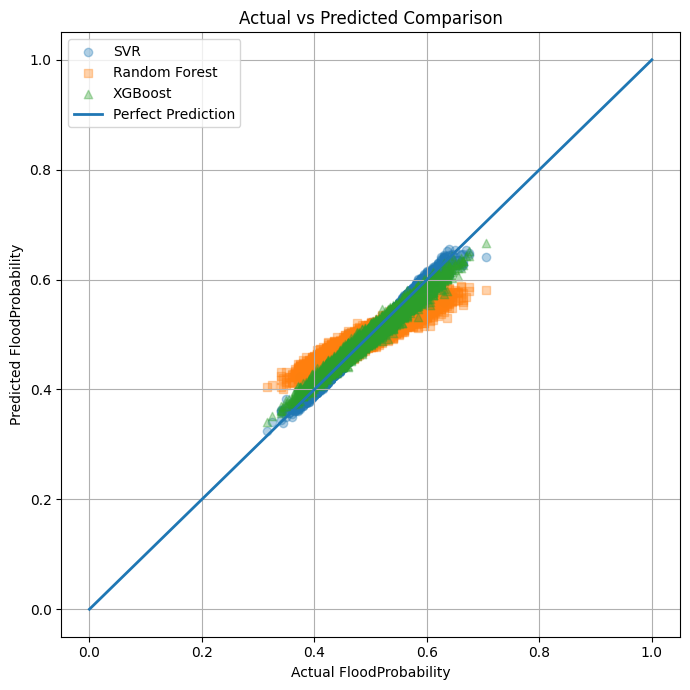

In [19]:
# ------------------------------------------------------------
# Visual comparison of model predictions
# Points closer to diagonal line = better prediction
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_svr, alpha=0.35, label="SVR", marker="o")
plt.scatter(y_test, y_pred_rf, alpha=0.35, label="Random Forest", marker="s")
plt.scatter(y_test, y_pred_xgb, alpha=0.35, label="XGBoost", marker="^")

# Perfect prediction reference line
plt.plot([0,1],[0,1], linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual FloodProbability")
plt.ylabel("Predicted FloodProbability")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

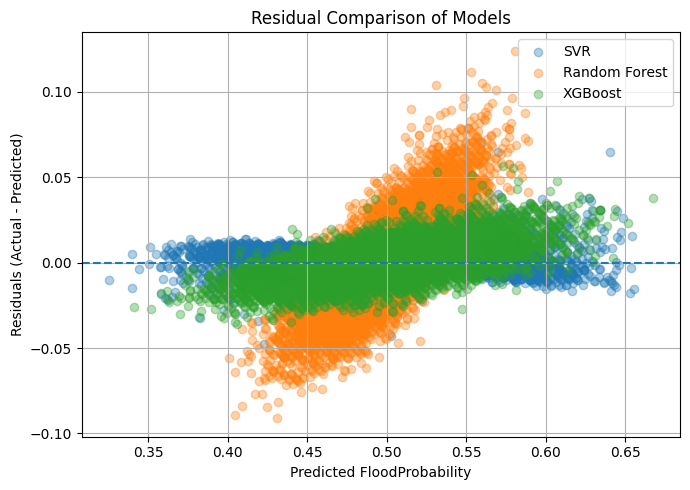

In [20]:
# ------------------------------------------------------------
# Residual Plot for SVR, Random Forest and XGBoost
# Residual = Actual - Predicted
# A good model shows random spread around 0 line
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Calculate residuals
res_svr = y_test - y_pred_svr
res_rf  = y_test - y_pred_rf
res_xgb = y_test - y_pred_xgb

plt.figure(figsize=(7,5))

# Plot residuals for each model
plt.scatter(y_pred_svr, res_svr, alpha=0.35, label="SVR")
plt.scatter(y_pred_rf,  res_rf,  alpha=0.35, label="Random Forest")
plt.scatter(y_pred_xgb, res_xgb, alpha=0.35, label="XGBoost")

# Reference horizontal line (perfect residual = 0)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted FloodProbability")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Comparison of Models")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# ------------------------------------------------------------
# Hyperparameter Tuning for Random Forest Regressor
# using RandomizedSearchCV
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
# Import Random Forest model
from sklearn.ensemble import RandomForestRegressor

# Define parameter search space
rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],   # number of trees
    "max_depth": [None, 10, 20, 30, 40],    # depth of each tree
    "min_samples_split": [2, 5, 10],        # minimum samples required to split
    "min_samples_leaf": [1, 2, 4],          # minimum samples in leaf node
    "max_features": ["sqrt", "log2", None], # number of features used in split
    "bootstrap": [True, False]              # sampling with replacement
}

# Create RandomizedSearchCV object
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,                # number of parameter combinations
    cv=3,                     # cross-validation folds
    scoring="r2",             # evaluation metric
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model (tree models do not require scaling)
rf_random.fit(X_train, y_train)

# Get best model
best_rf = rf_random.best_estimator_

# Make predictions
y_pred_rf_tuned = best_rf.predict(X_test)

# Print best parameters
print("Best Random Forest Parameters:", rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)

# Evaluate performance
print("\n------ Tuned Random Forest Performance ------")
print("R2 Score :", r2_score(y_test, y_pred_rf_tuned))
print("MAE      :", mean_absolute_error(y_test, y_pred_rf_tuned))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Random Forest Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None, 'bootstrap': True}
Best CV Score: 0.7240440075009342

------ Tuned Random Forest Performance ------
R2 Score : 0.7322435743735072
MAE      : 0.02034435776009825
RMSE     : 0.025823832722173527


In [23]:
# ------------------------------------------------------------
# Hyperparameter Tuning for XGBoost Regressor
# using RandomizedSearchCV
# ------------------------------------------------------------

# Import XGBoost model
from xgboost import XGBRegressor

# Define parameter search space
xgb_param_dist = {
    "n_estimators": [100, 200, 300, 500],   # number of boosting trees
    "learning_rate": [0.01, 0.05, 0.1, 0.2],# step size
    "max_depth": [3, 4, 5, 6, 8],           # depth of trees
    "subsample": [0.6, 0.8, 1.0],           # fraction of samples used
    "colsample_bytree": [0.6, 0.8, 1.0],    # fraction of features used
    "min_child_weight": [1, 3, 5],          # minimum sum of instance weight
    "gamma": [0, 0.1, 0.3]                  # minimum loss reduction
}

# Create RandomizedSearchCV object
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,           # random combinations
    cv=3,                # cross-validation folds
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model
xgb_random.fit(X_train, y_train)

# Best model
best_xgb = xgb_random.best_estimator_

# Predictions
y_pred_xgb_tuned = best_xgb.predict(X_test)

# Print best parameters
print("Best XGBoost Parameters:", xgb_random.best_params_)
print("Best CV Score:", xgb_random.best_score_)

# Evaluate model
print("\n------ Tuned XGBoost Performance ------")
print("R2 Score :", r2_score(y_test, y_pred_xgb_tuned))
print("MAE      :", mean_absolute_error(y_test, y_pred_xgb_tuned))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV Score: 0.9768489458151604

------ Tuned XGBoost Performance ------
R2 Score : 0.980671194144708
MAE      : 0.005488035971522331
RMSE     : 0.006938302984657112


In [24]:
# Hyperparameter Tuning for SVR using RandomizedSearchCV

from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Define a smaller parameter search space to reduce training time
svr_param_dist = {
    "kernel": ["rbf"],          # using rbf kernel
    "C": [1, 10],               # regularization values
    "epsilon": [0.01, 0.1],     # epsilon values
    "gamma": ["scale"]          # gamma setting
}

# RandomizedSearchCV to find best parameters
svr_random = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=svr_param_dist,
    n_iter=3,          # number of parameter combinations to try
    cv=2,              # 2-fold cross validation
    scoring="r2",      # evaluation metric
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train the model on scaled training data
svr_random.fit(X_train_scaled, y_train)

# Get the best model from tuning
best_svr = svr_random.best_estimator_

# Predict on test data
y_pred_svr_tuned = best_svr.predict(X_test_scaled)

# Print best parameters
print("Best SVR Parameters:", svr_random.best_params_)
print("Best CV Score:", svr_random.best_score_)

# Evaluate tuned model
print("\n------ Tuned SVR Performance ------")
print("R2 Score :", r2_score(y_test, y_pred_svr_tuned))
print("MAE      :", mean_absolute_error(y_test, y_pred_svr_tuned))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned)))

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best SVR Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.01, 'C': 1}
Best CV Score: 0.9819015047476541

------ Tuned SVR Performance ------
R2 Score : 0.9865606859367066
MAE      : 0.00418253990593599
RMSE     : 0.005785478719329752
